# EEG-Based Emotion Recognition — DEAP Preprocessing Pipeline
## Case Study 2 | Sanjeev Veeramani | Matriculation No. 100004303
### Supervisor: Prof. Dr. Binh Vu | SRH University Heidelberg

**Objective:** Build a complete preprocessing pipeline for the DEAP dataset — clean, filter, segment, normalize, and prepare labels for spatiotemporal deep learning models.

**Dataset:** DEAP (Database for Emotion Analysis using Physiological Signals)  
**Source:** Koelstra et al. (2012), IEEE Transactions on Affective Computing  
**Role:** Training + Validation dataset

---

## 1. Environment Setup

In [ ]:
# Run this cell ONCE to install required packages, then comment it out
# !pip install mne numpy scipy matplotlib seaborn pandas openpyxl

In [1]:
import numpy as np
import pickle
import os
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import butter, filtfilt
from scipy.stats import zscore
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2. Configuration

All file paths defined here. Update these to match your machine.

In [7]:
# ============================================================
# FILE PATHS — Update these to match your machine
# ============================================================

DEAP_DATA_DIR = r"V:\Data_Analytics\case study 2\deap datset kaggle\deap-dataset\data_preprocessed_python"
DEAP_METADATA_DIR = r"V:\Data_Analytics\case study 2\deap datset kaggle\deap-dataset\metadata_xls"
SEED_CHANNEL_FILE = r"V:\Data_Analytics\case study 2\seed dataset\channel_62_pos.locs"  # Update path
OUTPUT_DIR = r"V:\Data_Analytics\case study 2\processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Preprocessing Parameters ---
DEAP_SRATE = 128     # Hz (preprocessed version, as per Koelstra et al. 2012)
LOW_FREQ = 4.0       # Hz — lower bound (removes slow drift)
HIGH_FREQ = 45.0     # Hz — upper bound (removes line noise, keeps gamma)
FILTER_ORDER = 5     # Butterworth filter order
WINDOW_SEC = 1       # Segmentation window length in seconds
OVERLAP = 0.5        # 50% overlap between windows
BASELINE_SEC = 3     # Pre-trial baseline duration in seconds

# --- Label Thresholds ---
VALENCE_HIGH = 5.5   # Above this → Positive
VALENCE_LOW = 4.5    # Below this → Negative
# Between VALENCE_LOW and VALENCE_HIGH → Neutral

print("Configuration loaded.")
print(f"DEAP data: {DEAP_DATA_DIR}")
print(f"Output: {OUTPUT_DIR}")

Configuration loaded.
DEAP data: V:\Data_Analytics\case study 2\deap datset kaggle\deap-dataset\data_preprocessed_python
Output: V:\Data_Analytics\case study 2\processed


## 3. Explore DEAP Dataset Structure

Before preprocessing, we first explore what the raw data looks like — shapes, ranges, and contents. This is how we understand the data, not by assuming.

In [8]:
# Load one subject to understand the data structure
sample_file = os.path.join(DEAP_DATA_DIR, 's01.dat')

with open(sample_file, 'rb') as f:
    raw = pickle.load(f, encoding='latin1')

# What keys does the file contain?
print("Keys in the .dat file:", list(raw.keys()))
print()

# Explore each key
for key in raw.keys():
    data = raw[key]
    print(f"'{key}':")
    print(f"  Type: {type(data)}")
    print(f"  Shape: {data.shape}")
    print(f"  Dtype: {data.dtype}")
    print(f"  Range: [{data.min():.4f}, {data.max():.4f}]")
    print()

Keys in the .dat file: ['labels', 'data']

'labels':
  Type: <class 'numpy.ndarray'>
  Shape: (40, 4)
  Dtype: float64
  Range: [0.0000, 9.0000]

'data':
  Type: <class 'numpy.ndarray'>
  Shape: (40, 40, 8064)
  Dtype: float64
  Range: [-206259.3944, 88203.7490]



In [9]:
# Understand the data dimensions
eeg_raw = raw['data']
labels_raw = raw['labels']

print("=" * 60)
print("DEAP DATA STRUCTURE (per subject)")
print("=" * 60)
print(f"\nEEG data shape: {eeg_raw.shape}")
print(f"  → {eeg_raw.shape[0]} trials (40 music video clips)")
print(f"  → {eeg_raw.shape[1]} channels (32 EEG + 8 peripheral)")
print(f"  → {eeg_raw.shape[2]} time points")
print(f"  → Duration: {eeg_raw.shape[2] / DEAP_SRATE:.1f} seconds per trial")
print(f"  → Breakdown: {BASELINE_SEC}s baseline + 60s stimulus = 63s")
print(f"  → Verify: 63 × {DEAP_SRATE} Hz = {63 * DEAP_SRATE} samples ✓")

print(f"\nLabels shape: {labels_raw.shape}")
print(f"  → {labels_raw.shape[0]} trials × {labels_raw.shape[1]} ratings")
print(f"  → Columns: [Valence, Arousal, Dominance, Liking]")
print(f"  → Rating scale: 1 to 9")

print(f"\nLabel ranges:")
label_names = ['Valence', 'Arousal', 'Dominance', 'Liking']
for i, name in enumerate(label_names):
    col = labels_raw[:, i]
    print(f"  {name}: min={col.min():.2f}, max={col.max():.2f}, mean={col.mean():.2f}")

DEAP DATA STRUCTURE (per subject)

EEG data shape: (40, 40, 8064)
  → 40 trials (40 music video clips)
  → 40 channels (32 EEG + 8 peripheral)
  → 8064 time points
  → Duration: 63.0 seconds per trial
  → Breakdown: 3s baseline + 60s stimulus = 63s
  → Verify: 63 × 128 Hz = 8064 samples ✓

Labels shape: (40, 4)
  → 40 trials × 4 ratings
  → Columns: [Valence, Arousal, Dominance, Liking]
  → Rating scale: 1 to 9

Label ranges:
  Valence: min=0.00, max=8.27, mean=3.12
  Arousal: min=1.00, max=8.15, mean=3.76
  Dominance: min=2.04, max=9.00, mean=5.90
  Liking: min=3.87, max=8.47, mean=6.85


## 4. Extract Channel Names

**DEAP channels:** The preprocessed `.dat` files store only numerical arrays without channel name metadata. Channel names follow the standard BioSemi 32-channel montage as documented in Koelstra et al. (2012), Table II. The first 32 channels are EEG; channels 33–40 are peripheral physiological signals (EOG, EMG, GSR, respiration, blood volume, temperature).

**SEED channels:** Loaded programmatically from the official `channel_62_pos.locs` file provided with the SEED dataset.

In [10]:
# ----- DEAP Channel Names -----
# Source: Koelstra et al. (2012), Table II — BioSemi 32-channel montage
# International 10-20 system electrode positions
# Channels 1-32: EEG | Channels 33-40: Peripheral (not used)

DEAP_CHANNELS = [
    'Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7',
    'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz',
    'Fp2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8',
    'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Fz', 'Cz'
]

print(f"DEAP EEG channels: {len(DEAP_CHANNELS)}")
print(f"Names: {DEAP_CHANNELS}")
print(f"\nNote: Channels are from Koelstra et al. (2012), Table II.")
print(f"First 32 of {eeg_raw.shape[1]} total channels are EEG; remaining 8 are peripheral signals.")

DEAP EEG channels: 32
Names: ['Fp1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'Oz', 'Pz', 'Fp2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'Fz', 'Cz']

Note: Channels are from Koelstra et al. (2012), Table II.
First 32 of 40 total channels are EEG; remaining 8 are peripheral signals.


In [11]:
# ----- SEED Channel Names -----
# Loaded from the official channel_62_pos.locs file (SJTU BCMI Lab)

try:
    with open(SEED_CHANNEL_FILE, 'r') as f:
        lines = f.readlines()
    
    SEED_CHANNELS = [line.strip().split()[-1] for line in lines if line.strip()]
    
    print(f"SEED EEG channels: {len(SEED_CHANNELS)} (loaded from channel_62_pos.locs)")
    print(f"Names: {SEED_CHANNELS}")

except FileNotFoundError:
    print(f"WARNING: SEED channel file not found at {SEED_CHANNEL_FILE}")
    print("SEED is still downloading. Using documented channel names as fallback.")
    print("These will be verified against the actual file once SEED download completes.")
    
    SEED_CHANNELS = [
        'FP1', 'FPZ', 'FP2', 'AF3', 'AF4', 'F7', 'F5', 'F3',
        'F1', 'FZ', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5',
        'FC3', 'FC1', 'FCZ', 'FC2', 'FC4', 'FC6', 'FT8', 'T7',
        'C5', 'C3', 'C1', 'CZ', 'C2', 'C4', 'C6', 'T8',
        'TP7', 'CP5', 'CP3', 'CP1', 'CPZ', 'CP2', 'CP4', 'CP6',
        'TP8', 'P7', 'P5', 'P3', 'P1', 'PZ', 'P2', 'P4',
        'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POZ', 'PO4', 'PO6',
        'PO8', 'CB1', 'O1', 'OZ', 'O2', 'CB2'
    ]
    print(f"\nFallback SEED channels: {len(SEED_CHANNELS)}")

SEED EEG channels: 62 (loaded from channel_62_pos.locs)
Names: ['Fp1', 'Fpz', 'Fp2', 'AF3', 'AF4', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'FT7', 'FC5', 'FC3', 'FC1', 'FCz', 'FC2', 'FC4', 'FC6', 'FT8', 'T7', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'T8', 'TP7', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2', 'CP4', 'CP6', 'TP8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'PO7', 'PO5', 'PO3', 'POz', 'PO4', 'PO6', 'PO8', 'CB1', 'O1', 'Oz', 'O2', 'CB2']


## 5. Channel Selection — Finding Common Channels

For cross-dataset evaluation (train on DEAP → test on SEED), both datasets must use the same set of EEG channels. We find the intersection of channel names using the international 10-20 naming standard.

In [12]:
# Standardize to uppercase for matching (e.g., 'Fp1' == 'FP1')
deap_upper = [ch.upper() for ch in DEAP_CHANNELS]
seed_upper = [ch.upper() for ch in SEED_CHANNELS]

# Find common channels (preserving DEAP ordering)
COMMON_CHANNELS = [ch for ch in deap_upper if ch in seed_upper]

# Get the index positions in each dataset
DEAP_COMMON_IDX = [deap_upper.index(ch) for ch in COMMON_CHANNELS]
SEED_COMMON_IDX = [seed_upper.index(ch) for ch in COMMON_CHANNELS]

print(f"DEAP channels:   {len(DEAP_CHANNELS)}")
print(f"SEED channels:   {len(SEED_CHANNELS)}")
print(f"Common channels: {len(COMMON_CHANNELS)}")
print(f"\nCommon channel names:")
print(f"{COMMON_CHANNELS}")

# Channels that exist only in one dataset
deap_only = [ch for ch in deap_upper if ch not in seed_upper]
seed_only = [ch for ch in seed_upper if ch not in deap_upper]
if deap_only:
    print(f"\nDEAP-only (will be dropped): {deap_only}")
if seed_only:
    print(f"SEED-only (will be dropped during SEED preprocessing): {seed_only}")
if not deap_only:
    print(f"\nAll {len(DEAP_CHANNELS)} DEAP channels found in SEED — no DEAP channels dropped.")

DEAP channels:   32
SEED channels:   62
Common channels: 32

Common channel names:
['FP1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1', 'P3', 'P7', 'PO3', 'O1', 'OZ', 'PZ', 'FP2', 'AF4', 'F4', 'F8', 'FC6', 'FC2', 'C4', 'T8', 'CP6', 'CP2', 'P4', 'P8', 'PO4', 'O2', 'FZ', 'CZ']
SEED-only (will be dropped during SEED preprocessing): ['FPZ', 'F5', 'F1', 'F2', 'F6', 'FT7', 'FC3', 'FCZ', 'FC4', 'FT8', 'C5', 'C1', 'C2', 'C6', 'TP7', 'CP3', 'CPZ', 'CP4', 'TP8', 'P5', 'P1', 'P2', 'P6', 'PO7', 'PO5', 'POZ', 'PO6', 'PO8', 'CB1', 'CB2']

All 32 DEAP channels found in SEED — no DEAP channels dropped.


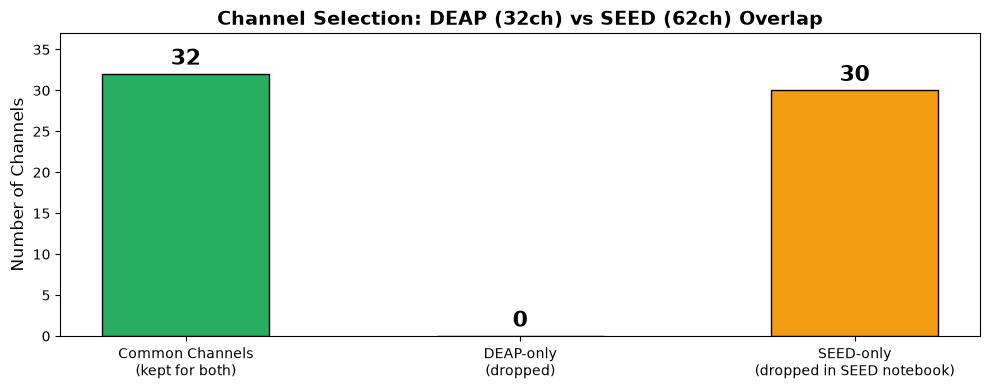

In [13]:
# Visualize channel overlap
fig, ax = plt.subplots(figsize=(10, 4))

categories = ['Common Channels\n(kept for both)', 'DEAP-only\n(dropped)', 'SEED-only\n(dropped in SEED notebook)']
counts = [len(COMMON_CHANNELS), len(deap_only), len(seed_only)]
colors = ['#27ae60', '#e74c3c', '#f39c12']

bars = ax.bar(categories, counts, color=colors, edgecolor='black', width=0.5)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=16)

ax.set_ylabel('Number of Channels', fontsize=12)
ax.set_title('Channel Selection: DEAP (32ch) vs SEED (62ch) Overlap', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(counts) + 5)
plt.tight_layout()
plt.show()

## 6. Load DEAP Data

Each `.dat` file contains one subject's data. We extract:
- **EEG only** (first 32 channels, discard 8 peripheral channels)
- **Labels** (valence, arousal, dominance, liking)

In [14]:
def load_deap_subject(filepath):
    """Load EEG data and labels from a single DEAP subject file.
    
    Returns:
        eeg_data: shape (40, 32, 8064) — 40 trials, 32 EEG channels, 8064 samples
        labels: shape (40, 4) — valence, arousal, dominance, liking
    """
    with open(filepath, 'rb') as f:
        data = pickle.load(f, encoding='latin1')
    
    eeg_data = data['data'][:, :32, :]   # First 32 channels = EEG only
    labels = data['labels']               # Shape: (40, 4)
    
    return eeg_data, labels

# Verify with Subject 01
eeg_s01, labels_s01 = load_deap_subject(os.path.join(DEAP_DATA_DIR, 's01.dat'))
print(f"Subject 01 loaded:")
print(f"  EEG shape: {eeg_s01.shape} → {eeg_s01.shape[0]} trials × {eeg_s01.shape[1]} EEG channels × {eeg_s01.shape[2]} time points")
print(f"  Labels shape: {labels_s01.shape}")

Subject 01 loaded:
  EEG shape: (40, 32, 8064) → 40 trials × 32 EEG channels × 8064 time points
  Labels shape: (40, 4)


## 7. Remove Baseline Period

Each DEAP trial includes a **3-second pre-stimulus baseline** at the start. This baseline captures the resting brain state before the music video begins and must be removed to keep only the 60-second stimulus-response period.

**Calculation:** 3 seconds × 128 Hz = 384 samples to remove from the start of each trial.

In [15]:
BASELINE_SAMPLES = BASELINE_SEC * DEAP_SRATE  # 3 × 128 = 384

def remove_baseline(eeg_data):
    """Remove the 3-second pre-stimulus baseline from each trial."""
    return eeg_data[:, :, BASELINE_SAMPLES:]

# Apply
eeg_no_baseline = remove_baseline(eeg_s01)

print(f"Before: {eeg_s01.shape} → {eeg_s01.shape[2] / DEAP_SRATE:.1f}s per trial (includes 3s baseline)")
print(f"After:  {eeg_no_baseline.shape} → {eeg_no_baseline.shape[2] / DEAP_SRATE:.1f}s per trial (stimulus only)")
print(f"Removed: {BASELINE_SAMPLES} samples ({BASELINE_SEC}s baseline)")

Before: (40, 32, 8064) → 63.0s per trial (includes 3s baseline)
After:  (40, 32, 7680) → 60.0s per trial (stimulus only)
Removed: 384 samples (3s baseline)


## 8. Apply Channel Selection

Keep only the common channels identified in Step 5.

In [16]:
def select_common_channels(eeg_data, channel_indices):
    """Select only channels that exist in both DEAP and SEED."""
    return eeg_data[:, channel_indices, :]

eeg_selected = select_common_channels(eeg_no_baseline, DEAP_COMMON_IDX)

print(f"Before: {eeg_no_baseline.shape[1]} channels (all DEAP EEG)")
print(f"After:  {eeg_selected.shape[1]} common channels")
print(f"Kept channels: {[COMMON_CHANNELS[i] for i in range(min(10, len(COMMON_CHANNELS)))]}...")

Before: 32 channels (all DEAP EEG)
After:  32 common channels
Kept channels: ['FP1', 'AF3', 'F3', 'F7', 'FC5', 'FC1', 'C3', 'T7', 'CP5', 'CP1']...


## 9. Bandpass Filtering (4–45 Hz)

We apply a Butterworth bandpass filter to retain only the EEG frequency bands relevant to emotion processing:

| Band | Range | Associated with |
|------|-------|----------------|
| Theta | 4–8 Hz | Emotional processing, memory |
| Alpha | 8–13 Hz | Relaxation, calm states |
| Beta | 13–30 Hz | Active thinking, engagement |
| Gamma | 30–45 Hz | High-level cognitive/emotional processing |

Frequencies below 4 Hz (slow drift, movement artifacts) and above 45 Hz (power line noise at 50 Hz, muscle artifacts) are removed.

**Decision:** 5th-order Butterworth bandpass, 4–45 Hz. Butterworth chosen for its maximally flat passband (minimal distortion of retained frequencies).

In [17]:
def bandpass_filter(data, low_freq, high_freq, srate, order=5):
    """Apply zero-phase Butterworth bandpass filter.
    
    Uses filtfilt for zero-phase filtering (no time delay introduced).
    
    Args:
        data: shape (trials, channels, time_points)
        low_freq, high_freq: cutoff frequencies in Hz
        srate: sampling rate in Hz
        order: filter order
    
    Returns:
        Filtered data with same shape
    """
    nyquist = srate / 2.0
    low = low_freq / nyquist
    high = high_freq / nyquist
    b, a = butter(order, [low, high], btype='band')
    
    filtered = np.zeros_like(data)
    n_trials, n_channels, n_points = data.shape
    
    for trial in range(n_trials):
        for ch in range(n_channels):
            filtered[trial, ch, :] = filtfilt(b, a, data[trial, ch, :])
    
    return filtered

# Apply
eeg_filtered = bandpass_filter(eeg_selected, LOW_FREQ, HIGH_FREQ, DEAP_SRATE, FILTER_ORDER)
print(f"Bandpass filter applied: {LOW_FREQ}–{HIGH_FREQ} Hz (order {FILTER_ORDER})")
print(f"Shape unchanged: {eeg_filtered.shape}")

Bandpass filter applied: 4.0–45.0 Hz (order 5)
Shape unchanged: (40, 32, 7680)


### Visual Proof: Before vs After Filtering

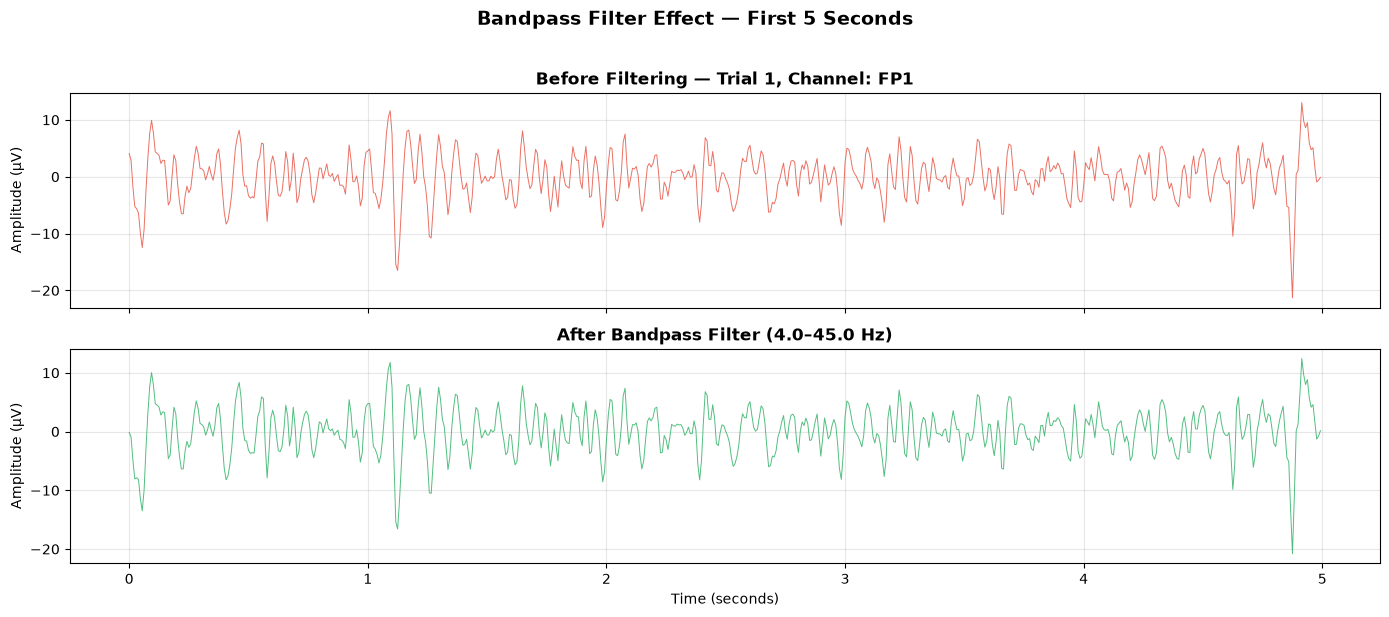

Observation: High-frequency noise and slow baseline drift removed.
Emotionally relevant frequency bands (theta, alpha, beta, gamma) retained.


In [18]:
# Show raw vs filtered for one trial, one channel
trial_idx, ch_idx = 0, 0
time_sec = np.arange(eeg_selected.shape[2]) / DEAP_SRATE

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Before
axes[0].plot(time_sec[:640], eeg_selected[trial_idx, ch_idx, :640], color='#e74c3c', linewidth=0.7, alpha=0.8)
axes[0].set_title(f'Before Filtering — Trial 1, Channel: {COMMON_CHANNELS[ch_idx]}', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)

# After
axes[1].plot(time_sec[:640], eeg_filtered[trial_idx, ch_idx, :640], color='#27ae60', linewidth=0.7, alpha=0.8)
axes[1].set_title(f'After Bandpass Filter ({LOW_FREQ}–{HIGH_FREQ} Hz)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amplitude (μV)')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Bandpass Filter Effect — First 5 Seconds', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observation: High-frequency noise and slow baseline drift removed.")
print("Emotionally relevant frequency bands (theta, alpha, beta, gamma) retained.")

## 10. Segmentation into Time Windows

Each 60-second trial is divided into fixed-length overlapping windows. Each window becomes one training sample for the deep learning models.

**Decisions:**
- **Window length:** 1 second (128 samples at 128 Hz) — short enough to capture transient emotional responses, long enough for meaningful frequency content
- **Overlap:** 50% — increases sample count and captures transitions between emotional states
- **Result:** Each 60s trial produces ~119 segments

In [19]:
def segment_data(data, window_samples, overlap_ratio=0.5):
    """Segment continuous trials into fixed-length overlapping windows.
    
    Args:
        data: shape (trials, channels, time_points)
        window_samples: samples per window
        overlap_ratio: fraction of overlap between consecutive windows
    
    Returns:
        segments: shape (total_segments, channels, window_samples)
        trial_indices: which trial each segment belongs to (for label mapping)
    """
    step = int(window_samples * (1 - overlap_ratio))
    n_trials, n_channels, n_points = data.shape
    
    segments = []
    trial_indices = []
    
    for trial in range(n_trials):
        start = 0
        while start + window_samples <= n_points:
            segments.append(data[trial, :, start:start + window_samples])
            trial_indices.append(trial)
            start += step
    
    return np.array(segments), np.array(trial_indices)

# Apply segmentation
window_samples = WINDOW_SEC * DEAP_SRATE  # 1s × 128 Hz = 128 samples
segments, trial_indices = segment_data(eeg_filtered, window_samples, OVERLAP)

step_samples = int(window_samples * (1 - OVERLAP))
print(f"Segmentation parameters:")
print(f"  Window: {WINDOW_SEC}s = {window_samples} samples")
print(f"  Overlap: {OVERLAP * 100:.0f}%")
print(f"  Step: {step_samples} samples ({step_samples / DEAP_SRATE:.3f}s)")
print(f"\nResult:")
print(f"  Before: {eeg_filtered.shape} (trials × channels × time)")
print(f"  After:  {segments.shape} (segments × channels × window)")
print(f"  → {segments.shape[0]} segments from {eeg_filtered.shape[0]} trials")
print(f"  → ~{segments.shape[0] // eeg_filtered.shape[0]} segments per trial")

Segmentation parameters:
  Window: 1s = 128 samples
  Overlap: 50%
  Step: 64 samples (0.500s)

Result:
  Before: (40, 32, 7680) (trials × channels × time)
  After:  (4760, 32, 128) (segments × channels × window)
  → 4760 segments from 40 trials
  → ~119 segments per trial


## 11. Z-Score Normalization

Z-score normalization (subtract mean, divide by standard deviation) is applied **per channel** across all segments of one subject.

**Why per subject:** Different people have different baseline brain signal amplitudes due to skull thickness, electrode impedance, etc. Normalizing per subject ensures the model learns *emotion patterns*, not *individual differences*.

In [20]:
def normalize_zscore(segments):
    """Z-score normalize per channel across all segments.
    
    Args:
        segments: shape (n_segments, n_channels, window_samples)
    
    Returns:
        Normalized segments (mean ≈ 0, std ≈ 1 per channel)
    """
    normalized = np.zeros_like(segments)
    for ch in range(segments.shape[1]):
        ch_data = segments[:, ch, :]
        mean = ch_data.mean()
        std = ch_data.std()
        if std > 0:
            normalized[:, ch, :] = (ch_data - mean) / std
        else:
            normalized[:, ch, :] = ch_data - mean
    return normalized

# Apply
segments_norm = normalize_zscore(segments)

# Verify normalization
print("Z-score normalization verification (first 5 channels):")
print(f"{'Channel':<12} {'Mean':>10} {'Std':>10}")
print("-" * 35)
for ch in range(min(5, segments_norm.shape[1])):
    ch_data = segments_norm[:, ch, :]
    print(f"{COMMON_CHANNELS[ch]:<12} {ch_data.mean():>10.6f} {ch_data.std():>10.6f}")
print("...  (all channels should show mean ≈ 0, std ≈ 1)")

Z-score normalization verification (first 5 channels):
Channel            Mean        Std
-----------------------------------
FP1            0.000000   1.000000
AF3           -0.000000   1.000000
F3            -0.000000   1.000000
F7            -0.000000   1.000000
FC5           -0.000000   1.000000
...  (all channels should show mean ≈ 0, std ≈ 1)


## 12. Label Preparation

We prepare three types of labels from DEAP's continuous valence-arousal ratings:

**Binary classification** (standard DEAP benchmarks):
- High vs Low Valence (threshold = 5)
- High vs Low Arousal (threshold = 5)

**3-class classification** (for cross-dataset alignment with SEED):
- Valence > 5.5 → **Positive** (2)
- 4.5 ≤ Valence ≤ 5.5 → **Neutral** (1)
- Valence < 4.5 → **Negative** (0)

This 3-class mapping enables direct comparison with SEED's positive/neutral/negative labels during cross-dataset evaluation.

In [21]:
def prepare_labels(labels, trial_indices):
    """Create binary and 3-class labels, mapped to segment level.
    
    Args:
        labels: shape (n_trials, 4) — [valence, arousal, dominance, liking]
        trial_indices: maps each segment to its source trial
    
    Returns:
        dict with 'binary_valence', 'binary_arousal', 'three_class' arrays
    """
    valence = labels[:, 0]
    arousal = labels[:, 1]
    
    # Binary (threshold = 5)
    bin_val = (valence > 5).astype(int)
    bin_aro = (arousal > 5).astype(int)
    
    # 3-class (SEED-aligned)
    three_class = np.ones(len(valence), dtype=int)  # Default: Neutral (1)
    three_class[valence > VALENCE_HIGH] = 2          # Positive
    three_class[valence < VALENCE_LOW] = 0           # Negative
    
    # Map trial-level labels to segment-level
    return {
        'binary_valence': bin_val[trial_indices],
        'binary_arousal': bin_aro[trial_indices],
        'three_class': three_class[trial_indices]
    }

# Apply to Subject 01
label_dict = prepare_labels(labels_s01, trial_indices)

print("Label distribution for Subject 01:")
print(f"\nBinary Valence — High: {(label_dict['binary_valence']==1).sum()}, Low: {(label_dict['binary_valence']==0).sum()}")
print(f"Binary Arousal — High: {(label_dict['binary_arousal']==1).sum()}, Low: {(label_dict['binary_arousal']==0).sum()}")
print(f"3-Class — Positive: {(label_dict['three_class']==2).sum()}, Neutral: {(label_dict['three_class']==1).sum()}, Negative: {(label_dict['three_class']==0).sum()}")

Label distribution for Subject 01:

Binary Valence — High: 714, Low: 4046
Binary Arousal — High: 1309, Low: 3451
3-Class — Positive: 714, Neutral: 119, Negative: 3927


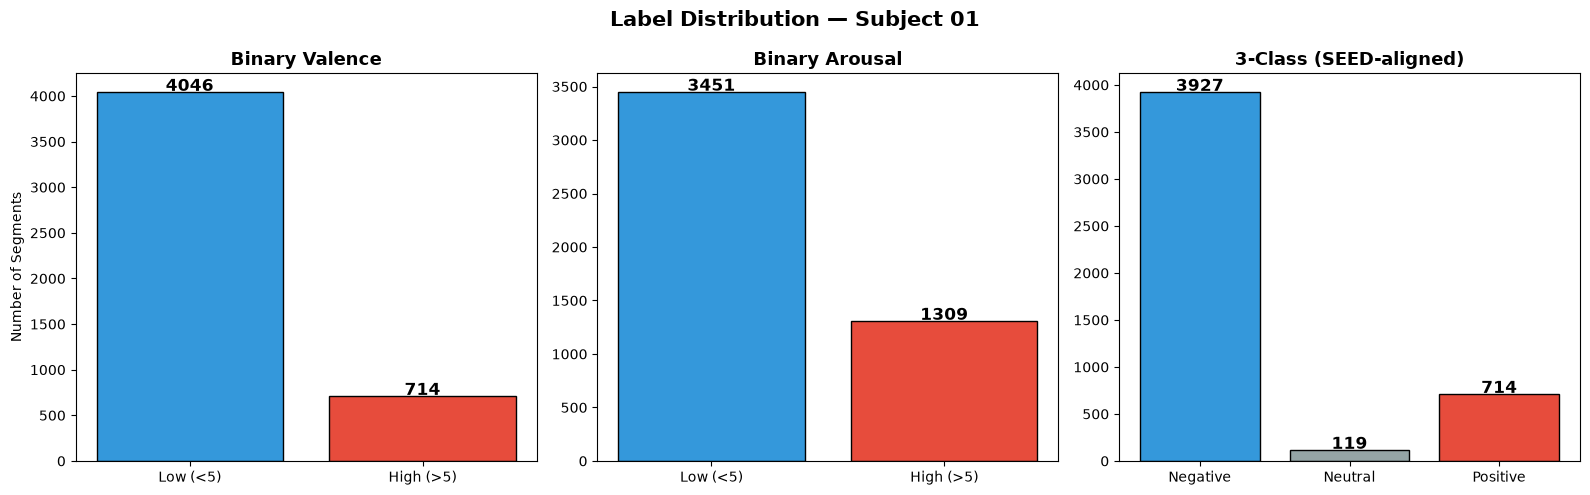

In [22]:
# Visualize label distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary Valence
vals, counts = np.unique(label_dict['binary_valence'], return_counts=True)
axes[0].bar(['Low (<5)', 'High (>5)'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Binary Valence', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Segments')
for i, c in enumerate(counts):
    axes[0].text(i, c + 10, str(c), ha='center', fontweight='bold', fontsize=12)

# Binary Arousal
vals, counts = np.unique(label_dict['binary_arousal'], return_counts=True)
axes[1].bar(['Low (<5)', 'High (>5)'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Binary Arousal', fontsize=13, fontweight='bold')
for i, c in enumerate(counts):
    axes[1].text(i, c + 10, str(c), ha='center', fontweight='bold', fontsize=12)

# 3-Class
vals, counts = np.unique(label_dict['three_class'], return_counts=True)
label_names = ['Negative', 'Neutral', 'Positive']
colors = ['#3498db', '#95a5a6', '#e74c3c']
axes[2].bar(label_names[:len(counts)], counts, color=colors[:len(counts)], edgecolor='black')
axes[2].set_title('3-Class (SEED-aligned)', fontsize=13, fontweight='bold')
for i, c in enumerate(counts):
    axes[2].text(i, c + 10, str(c), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Label Distribution — Subject 01', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 13. Full Pipeline — Process All 32 DEAP Subjects

Combining all preprocessing steps into a single function and running it across all subjects.

In [23]:
def preprocess_deap_subject(filepath, common_ch_idx):
    """Complete preprocessing pipeline for one DEAP subject.
    
    Steps: Load → Remove baseline → Select channels → Bandpass filter → Segment → Normalize
    """
    # Load
    eeg_data, labels = load_deap_subject(filepath)
    
    # Remove 3s baseline
    eeg_data = remove_baseline(eeg_data)
    
    # Keep common channels only
    eeg_data = select_common_channels(eeg_data, common_ch_idx)
    
    # Bandpass filter (4–45 Hz)
    eeg_data = bandpass_filter(eeg_data, LOW_FREQ, HIGH_FREQ, DEAP_SRATE, FILTER_ORDER)
    
    # Segment into 1s windows with 50% overlap
    window_samples = WINDOW_SEC * DEAP_SRATE
    segments, trial_indices = segment_data(eeg_data, window_samples, OVERLAP)
    
    # Z-score normalize per channel
    segments = normalize_zscore(segments)
    
    # Prepare labels
    label_dict = prepare_labels(labels, trial_indices)
    
    return segments, label_dict, trial_indices

# ---- Process all 32 subjects ----
all_segments = []
all_labels_bv = []
all_labels_ba = []
all_labels_3c = []
all_subject_ids = []

print("Processing all 32 DEAP subjects...")
print("-" * 60)

for subj in range(1, 33):
    filepath = os.path.join(DEAP_DATA_DIR, f's{subj:02d}.dat')
    
    if not os.path.exists(filepath):
        print(f"  ⚠ Subject {subj:02d}: File not found, skipping.")
        continue
    
    segments, label_dict, _ = preprocess_deap_subject(filepath, DEAP_COMMON_IDX)
    
    all_segments.append(segments)
    all_labels_bv.append(label_dict['binary_valence'])
    all_labels_ba.append(label_dict['binary_arousal'])
    all_labels_3c.append(label_dict['three_class'])
    all_subject_ids.append(np.full(len(segments), subj))
    
    print(f"  ✓ Subject {subj:02d}: {segments.shape[0]} segments, shape per segment: {segments.shape[1:]}")

# Combine
X_deap = np.concatenate(all_segments, axis=0)
y_valence = np.concatenate(all_labels_bv)
y_arousal = np.concatenate(all_labels_ba)
y_3class = np.concatenate(all_labels_3c)
subject_ids = np.concatenate(all_subject_ids)

print(f"\n{'=' * 60}")
print(f"DEAP PREPROCESSING COMPLETE")
print(f"{'=' * 60}")
print(f"Total segments:    {X_deap.shape[0]}")
print(f"Segment shape:     {X_deap.shape[1:]} (channels × window)")
print(f"Subjects:          {len(np.unique(subject_ids))}")
print(f"Memory:            {X_deap.nbytes / (1024**2):.1f} MB")

Processing all 32 DEAP subjects...
------------------------------------------------------------
  ✓ Subject 01: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 02: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 03: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 04: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 05: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 06: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 07: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 08: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 09: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 10: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 11: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 12: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 13: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 14: 4760 segments, shape per segment: (32, 128)
  ✓ Subject 15: 4760 segments, shape per segment: (32, 128)
  ✓ 

## 14. Overall Label Distribution (All 32 Subjects)

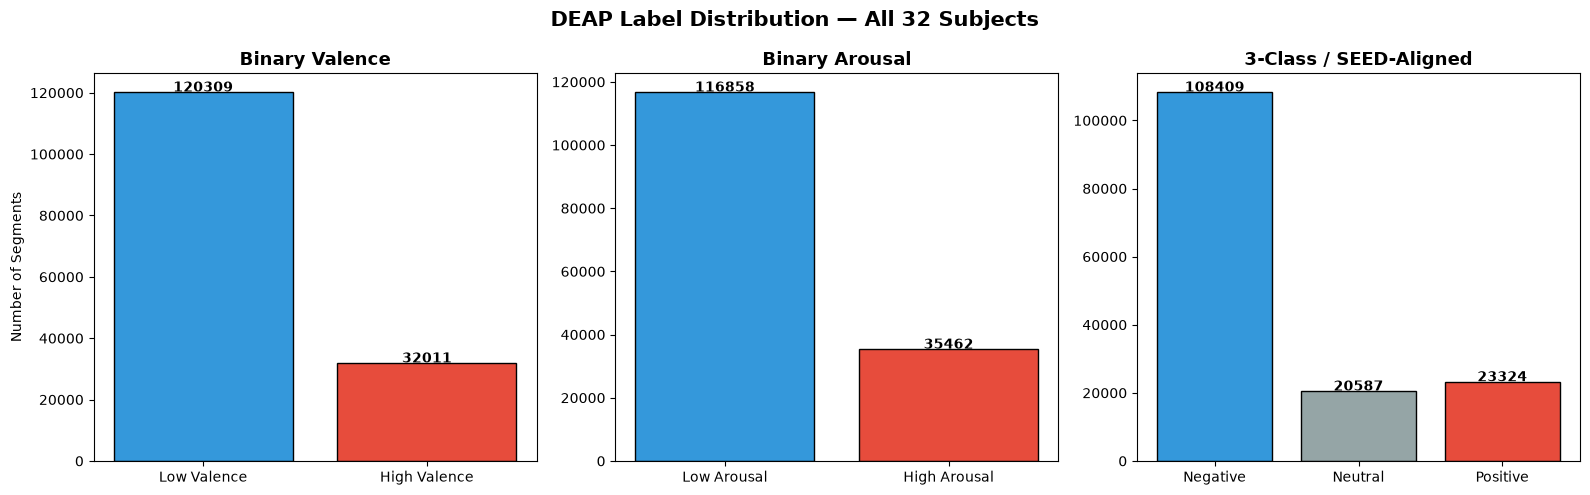

Total: 152320 segments
3-Class balance: Negative=108409, Neutral=20587, Positive=23324


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Binary Valence
vals, counts = np.unique(y_valence, return_counts=True)
axes[0].bar(['Low Valence', 'High Valence'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Binary Valence', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Segments')
for i, c in enumerate(counts): axes[0].text(i, c+100, str(c), ha='center', fontweight='bold')

# Binary Arousal
vals, counts = np.unique(y_arousal, return_counts=True)
axes[1].bar(['Low Arousal', 'High Arousal'], counts, color=['#3498db', '#e74c3c'], edgecolor='black')
axes[1].set_title('Binary Arousal', fontsize=13, fontweight='bold')
for i, c in enumerate(counts): axes[1].text(i, c+100, str(c), ha='center', fontweight='bold')

# 3-Class
vals, counts = np.unique(y_3class, return_counts=True)
names = ['Negative', 'Neutral', 'Positive']
colors = ['#3498db', '#95a5a6', '#e74c3c']
axes[2].bar(names[:len(counts)], counts, color=colors[:len(counts)], edgecolor='black')
axes[2].set_title('3-Class / SEED-Aligned', fontsize=13, fontweight='bold')
for i, c in enumerate(counts): axes[2].text(i, c+100, str(c), ha='center', fontweight='bold')

plt.suptitle('DEAP Label Distribution — All 32 Subjects', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Total: {len(y_3class)} segments")
print(f"3-Class balance: Negative={sum(y_3class==0)}, Neutral={sum(y_3class==1)}, Positive={sum(y_3class==2)}")

## 15. Save Processed Data

In [25]:
# Save all processed arrays
np.save(os.path.join(OUTPUT_DIR, 'X_deap.npy'), X_deap)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_valence.npy'), y_valence)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_arousal.npy'), y_arousal)
np.save(os.path.join(OUTPUT_DIR, 'y_deap_3class.npy'), y_3class)
np.save(os.path.join(OUTPUT_DIR, 'deap_subject_ids.npy'), subject_ids)

# Also save common channel info for the SEED notebook
np.save(os.path.join(OUTPUT_DIR, 'common_channels.npy'), np.array(COMMON_CHANNELS))
np.save(os.path.join(OUTPUT_DIR, 'seed_common_idx.npy'), np.array(SEED_COMMON_IDX))

print(f"Saved to: {OUTPUT_DIR}\n")
for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.endswith('.npy'):
        fpath = os.path.join(OUTPUT_DIR, f)
        size_mb = os.path.getsize(fpath) / (1024**2)
        print(f"  {f}: {size_mb:.1f} MB")

Saved to: V:\Data_Analytics\case study 2\processed

  X_deap.npy: 4760.0 MB
  common_channels.npy: 0.0 MB
  deap_subject_ids.npy: 1.2 MB
  seed_common_idx.npy: 0.0 MB
  y_deap_3class.npy: 1.2 MB
  y_deap_arousal.npy: 1.2 MB
  y_deap_valence.npy: 1.2 MB


## 16. Data Split Strategy (Box 4)

**Leave-One-Subject-Out (LOSO) Cross-Validation:**
- Train on 31 subjects, validate on 1 subject
- Repeat 32 times (each subject takes a turn as the validation set)
- Guarantees the model generalizes to *unseen subjects*, not just unseen trials from known subjects

**Why LOSO:** Subject-level splitting prevents data leakage. If segments from the same subject appear in both training and validation, the model can exploit individual-specific patterns (brain anatomy, electrode impedance) rather than learning generalizable emotion representations.

**SEED:** Reserved as external test set only — no training, no fine-tuning.

In [26]:
def get_loso_splits(subject_ids):
    """Generate Leave-One-Subject-Out cross-validation splits.
    
    Returns:
        List of (train_indices, val_indices) tuples
    """
    unique_subjects = np.unique(subject_ids)
    splits = []
    for val_subj in unique_subjects:
        train_idx = np.where(subject_ids != val_subj)[0]
        val_idx = np.where(subject_ids == val_subj)[0]
        splits.append((train_idx, val_idx))
    return splits

# Generate and verify splits
splits = get_loso_splits(subject_ids)

print(f"Leave-One-Subject-Out Cross-Validation")
print(f"  Total folds: {len(splits)}")
print(f"\nExample splits:")
for i in [0, 15, 31]:
    if i < len(splits):
        train_idx, val_idx = splits[i]
        print(f"  Fold {i+1} (val=Subject {i+1}): Train={len(train_idx)} samples ({len(train_idx)/len(subject_ids)*100:.1f}%), Val={len(val_idx)} samples ({len(val_idx)/len(subject_ids)*100:.1f}%)")

print(f"\nNo data leakage: train and val sets never share the same subject. ✓")
print(f"SEED: reserved as external test set (no training/fine-tuning). ✓")

Leave-One-Subject-Out Cross-Validation
  Total folds: 32

Example splits:
  Fold 1 (val=Subject 1): Train=147560 samples (96.9%), Val=4760 samples (3.1%)
  Fold 16 (val=Subject 16): Train=147560 samples (96.9%), Val=4760 samples (3.1%)
  Fold 32 (val=Subject 32): Train=147560 samples (96.9%), Val=4760 samples (3.1%)

No data leakage: train and val sets never share the same subject. ✓
SEED: reserved as external test set (no training/fine-tuning). ✓


## 17. Preprocessing Summary

| Step | Description | Decision/Result |
|------|-------------|----------------|
| 1. Dataset Exploration | Inspected DEAP `.dat` file structure | 40 trials × 40 channels × 8064 samples per subject |
| 2. Channel Extraction | DEAP: from paper; SEED: from `channel_62_pos.locs` | 32 DEAP + 62 SEED channels identified |
| 3. Channel Selection | Common channels between DEAP and SEED | All 32 DEAP channels found in SEED |
| 4. Baseline Removal | Remove 3s pre-stimulus baseline | 384 samples removed, 60s per trial retained |
| 5. Bandpass Filter | Butterworth 4–45 Hz, order 5, zero-phase | Theta, Alpha, Beta, Gamma bands retained |
| 6. Segmentation | 1-second windows, 50% overlap | ~119 segments per trial |
| 7. Z-Score Normalization | Per channel, per subject | Mean ≈ 0, Std ≈ 1 per channel |
| 8. Label Mapping | Binary (threshold=5) + 3-class (SEED-aligned) | See distribution plots above |
| 9. Data Split | Leave-One-Subject-Out (32 folds) | No leakage; SEED = external test only |

**Processed data saved and ready for feature engineering and model training (Report 2).**

---
*Sanjeev Veeramani | M.Sc. Applied Data Science and Analytics | SRH University Heidelberg | July 2026*